# Rajasthan Heatwave Prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df=pd.read_csv('Rajasthan_Heatwave_2006_2025.csv')

## 1. Data Exploration

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21960 entries, 0 to 21959
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YEAR      21960 non-null  int64  
 1   MONTH     21960 non-null  int64  
 2   DAY       21960 non-null  int64  
 3   WIND_U10  21960 non-null  float64
 4   WIND_V10  21960 non-null  float64
 5   MSLP      21960 non-null  float64
 6   BLH       21960 non-null  float64
 7   GEOP      21960 non-null  float64
 8   TEMP2M    21960 non-null  float64
 9   TMAX      21960 non-null  float64
 10  TMIN      21960 non-null  float64
 11  DEW2M     21960 non-null  float64
 12  CLOUD     21960 non-null  float64
 13  RAIN      21960 non-null  float64
 14  SRAD      21960 non-null  int64  
 15  EVAP      21960 non-null  float64
 16  SOILT1    21960 non-null  float64
 17  SOILM1    21960 non-null  float64
 18  LAI       21960 non-null  float64
 19  HEATWAVE  21960 non-null  int64  
 20  LAT       21960 non-null  fl

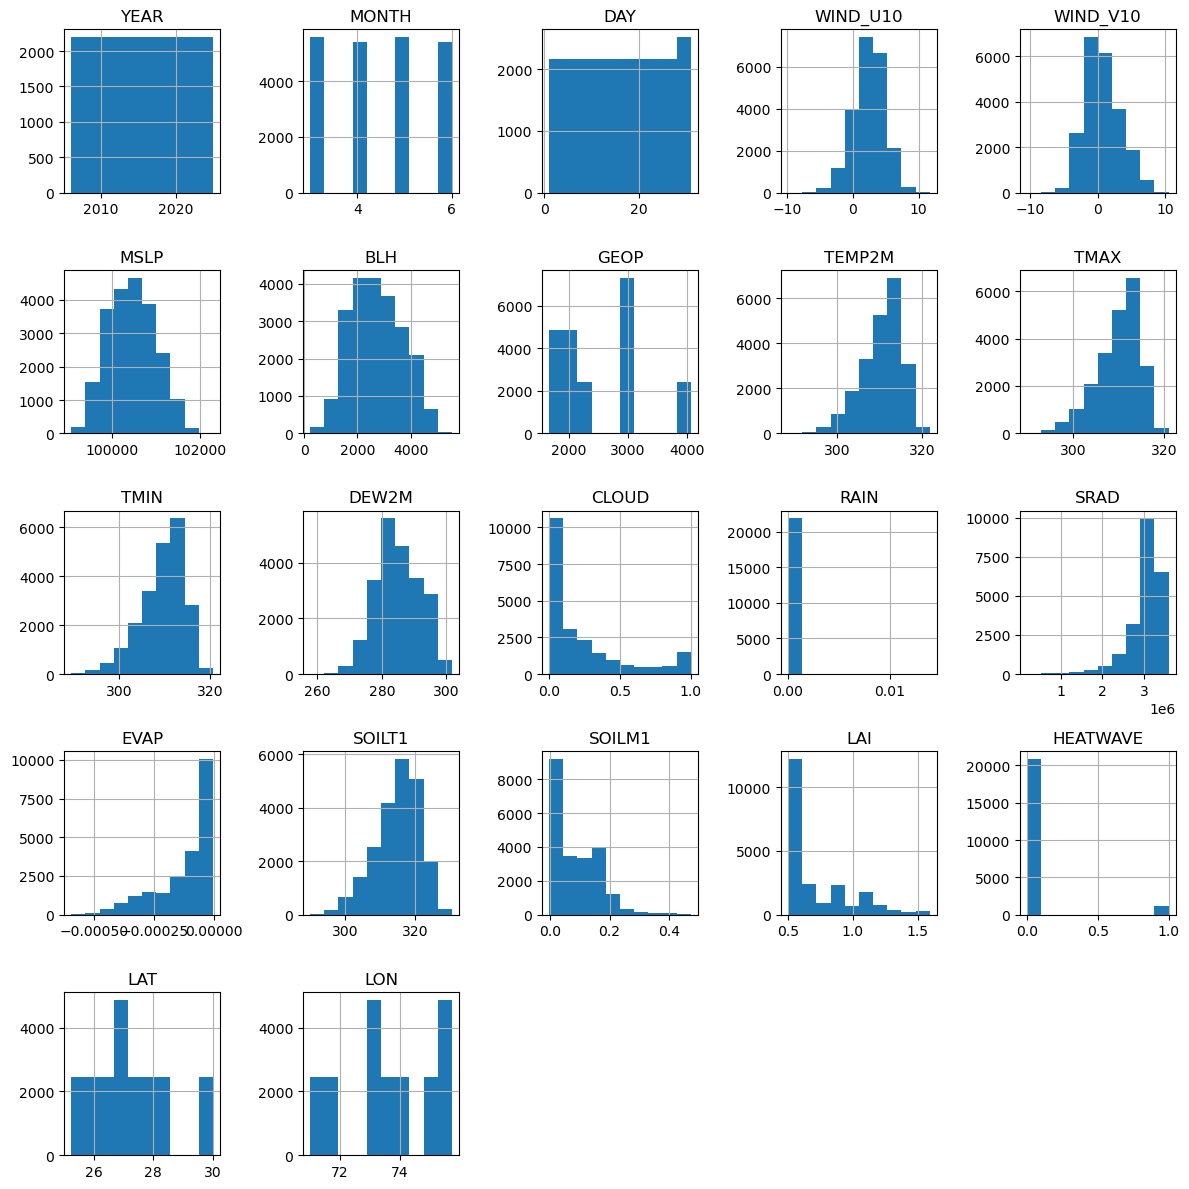

In [25]:
df.hist(figsize=(12,12),bins=10)
plt.tight_layout()
plt.show()

In [26]:
df.describe()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,CLOUD,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON
count,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,...,21960.000000,21960.000000,2.196000e+04,21960.000000,21960.000000,21960.000000,21960.000000,21960.00000,21960.000000,21960.000000
mean,2015.500000,4.491803,15.754098,2.475624,0.723588,100444.274043,2720.154134,2533.205122,310.489501,310.012704,...,0.229915,0.000025,3.018293e+06,-0.000121,314.923305,0.088897,0.705440,0.05000,27.194444,73.666667
std,5.766413,1.118029,8.807157,2.378115,2.603999,528.394425,956.843798,730.211149,4.823235,4.749862,...,0.292535,0.000240,3.899573e+05,0.000119,6.217636,0.074033,0.255386,0.21795,1.352897,1.598647
min,2006.000000,3.000000,1.000000,-9.852875,-10.506165,99062.310000,218.709060,1671.107900,288.333000,289.821780,...,0.000000,0.000000,1.964800e+05,-0.000597,290.145020,-0.003362,0.500000,0.00000,25.250000,71.000000
25%,2010.750000,3.000000,8.000000,0.951839,-1.194061,100032.013750,1967.295925,2038.498500,307.645260,307.107242,...,0.000000,0.000000,2.905536e+06,-0.000176,311.116080,0.025887,0.515625,0.00000,26.250000,73.000000
50%,2015.500000,4.500000,16.000000,2.605873,0.396530,100434.190000,2651.828500,2180.979000,311.434685,311.036625,...,0.110153,0.000000,3.129056e+06,-0.000075,315.802735,0.068370,0.596314,0.00000,27.000000,73.750000
75%,2020.250000,5.000000,23.000000,4.078281,2.403336,100830.265000,3439.665600,2989.502400,313.963740,313.455083,...,0.329498,0.000000,3.265216e+06,-0.000032,319.461490,0.144219,0.857788,0.00000,28.000000,75.000000
max,2025.000000,6.000000,31.000000,11.707886,10.517532,102289.690000,5547.617700,4063.225000,321.840100,320.959960,...,1.000000,0.013919,3.579648e+06,-0.000004,330.317380,0.473269,1.592163,1.00000,30.000000,75.750000


## 2. Exploratory Data Analysis

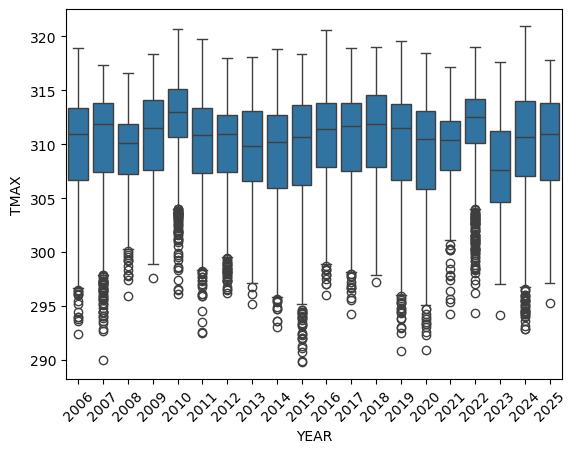

In [27]:
sns.boxplot(x='YEAR',y='TMAX',data=df)
plt.xticks(rotation=45)
plt.show()

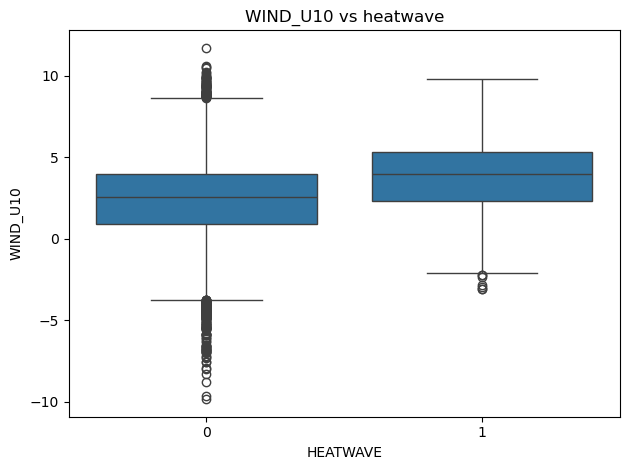

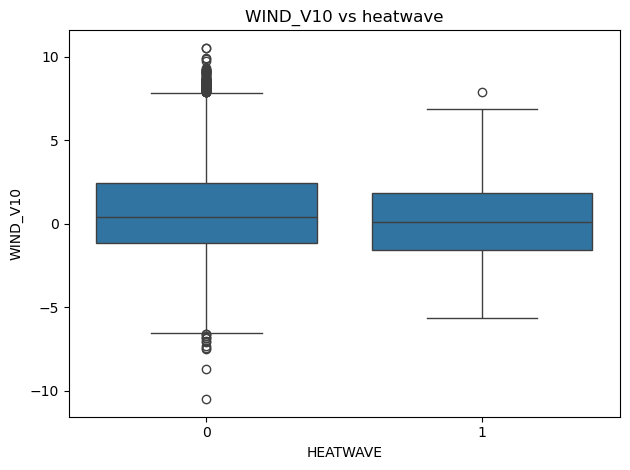

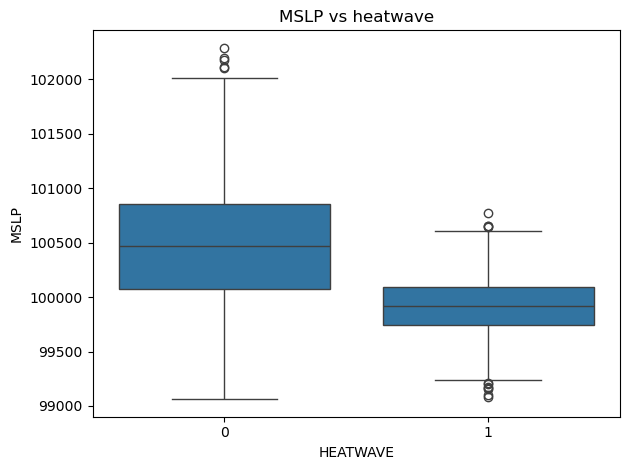

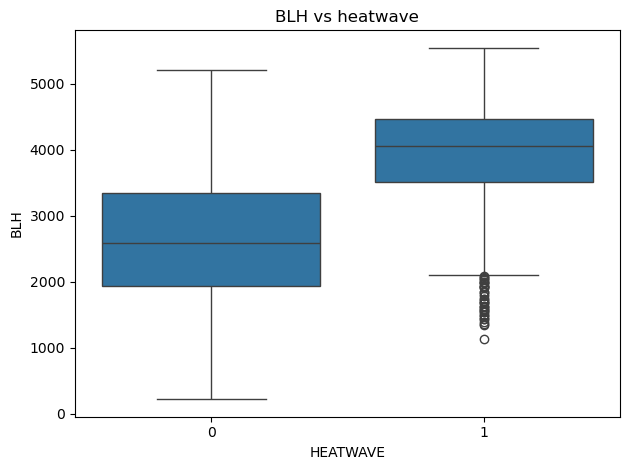

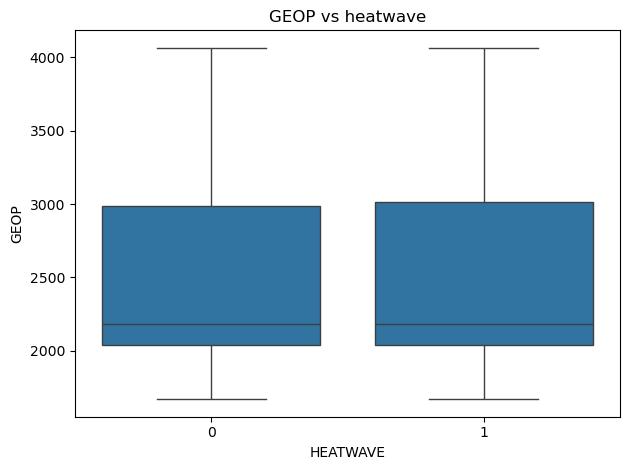

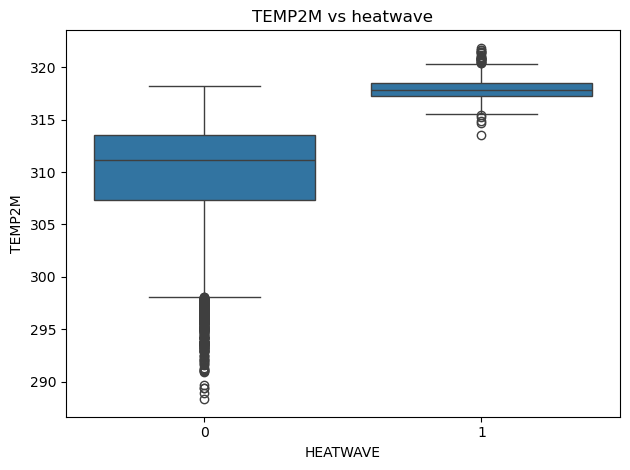

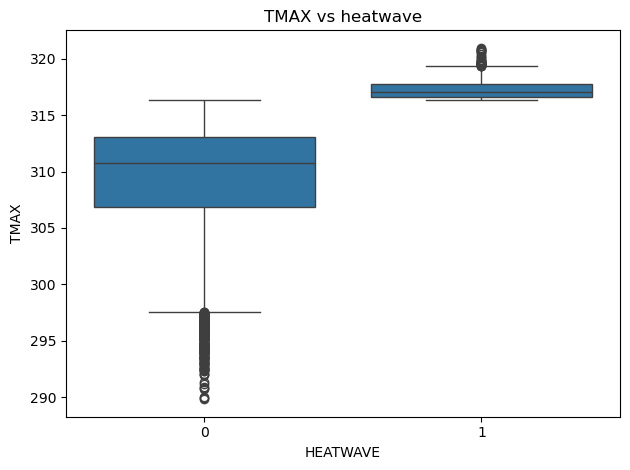

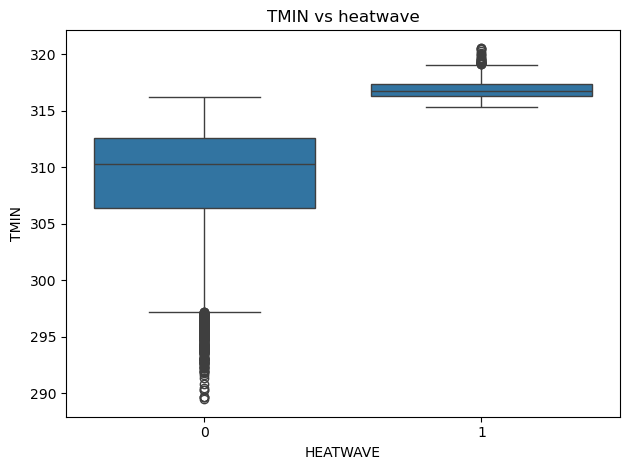

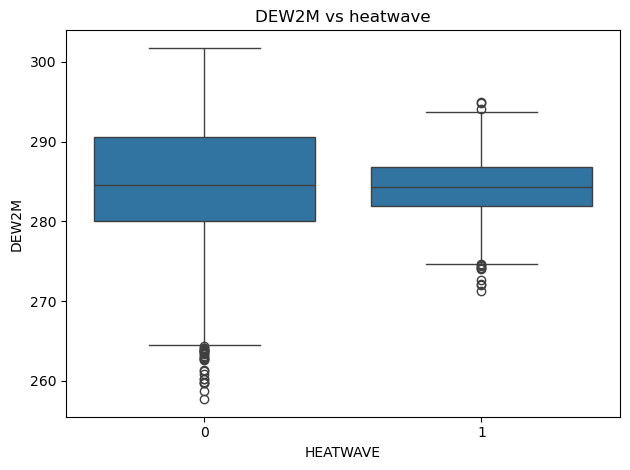

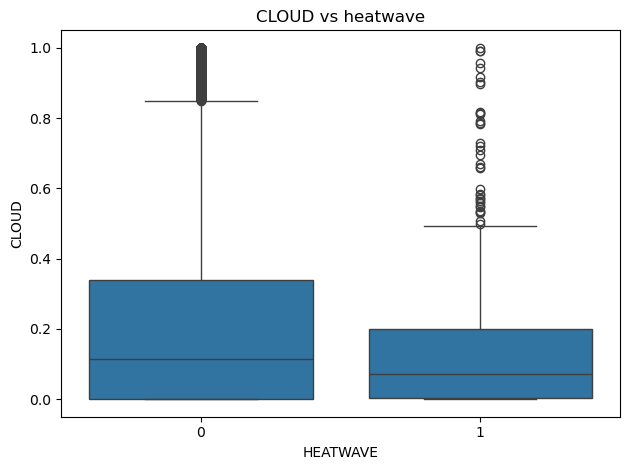

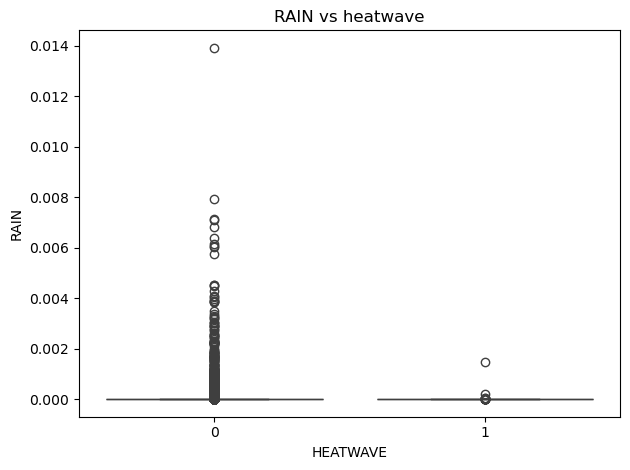

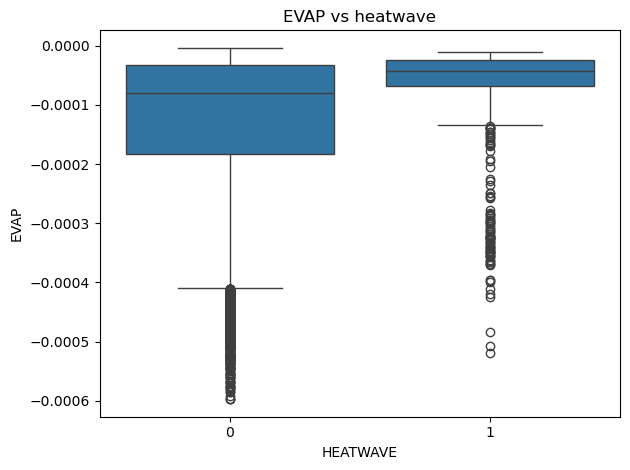

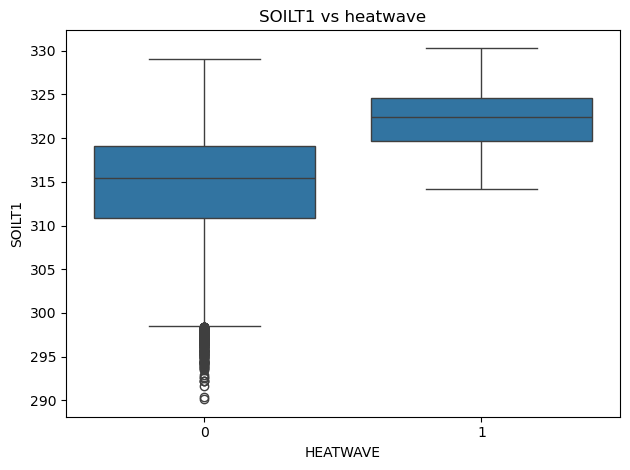

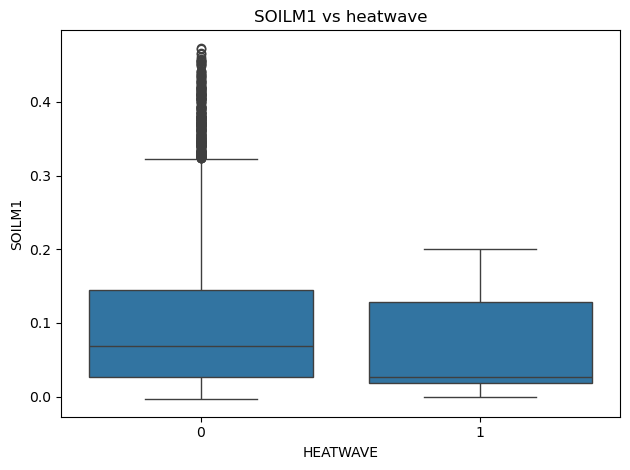

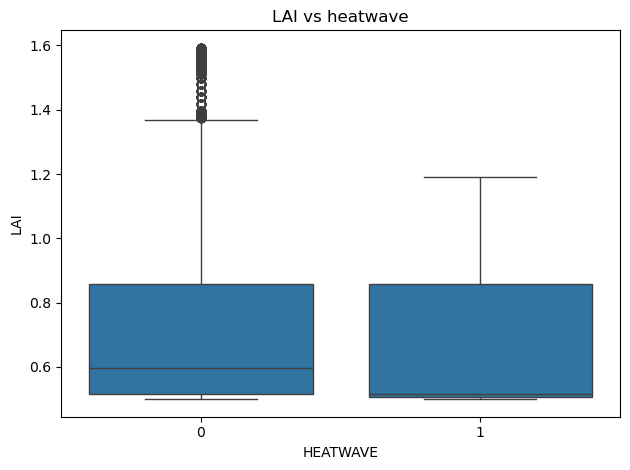

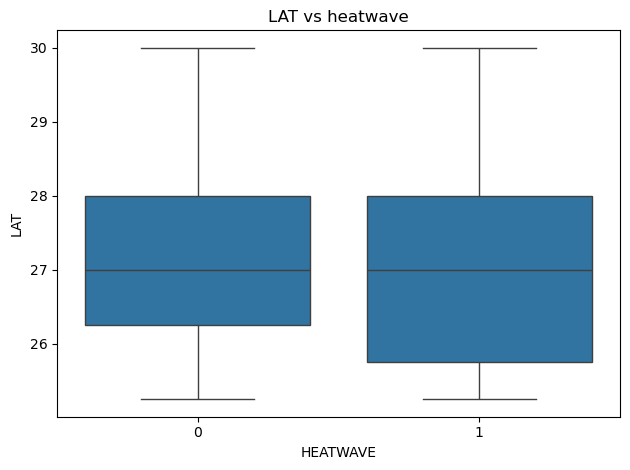

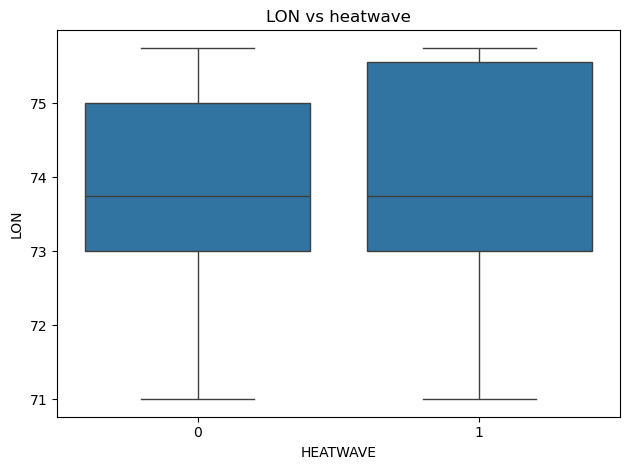

In [28]:
for cols in df.select_dtypes(include='float').columns:
    sns.boxplot(x='HEATWAVE',y=cols,data=df)
    plt.title(f"{cols} vs heatwave")
    plt.tight_layout()
    plt.show()



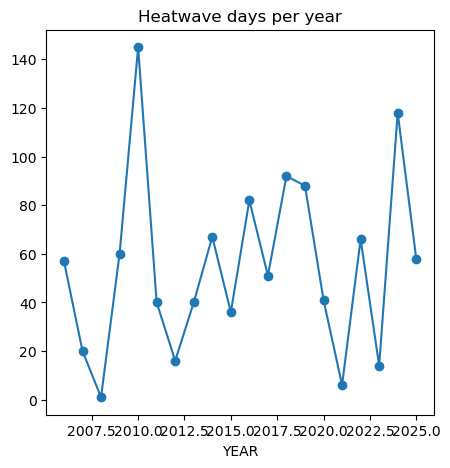

In [29]:
yearly=df.groupby('YEAR')['HEATWAVE'].sum()
yearly.plot(kind='line', marker='o', figsize=(5,5))
plt.title('Heatwave days per year')
plt.show()

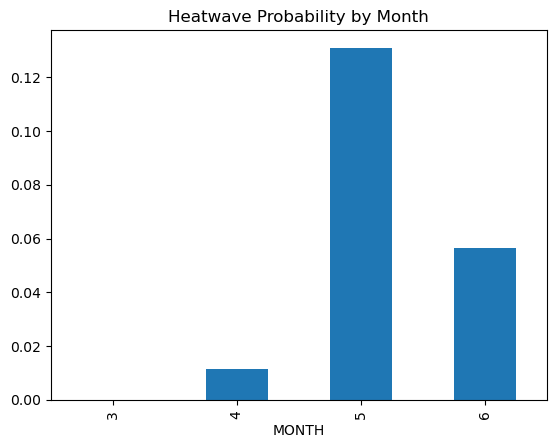

In [30]:
monthly=df.groupby('MONTH')['HEATWAVE'].mean()
monthly.plot(kind='bar')
plt.title('Heatwave Probability by Month')
plt.show()

## 3. Feature Engineering (Time Series)

In [31]:
df['DATE']=pd.to_datetime(df[['YEAR','MONTH','DAY']])
df=df.sort_values('DATE')

In [32]:
df['TMAX_lag1'] = df['TMAX'].shift(1)
df['TMAX_rolling3'] = df['TMAX'].rolling(3).mean()


In [33]:
df.drop(columns=['DAY'], inplace=True)

In [34]:
# Option 1 - simplest, just drop those few rows
df.dropna(subset=['TMAX_lag1', 'TMAX_rolling3'], inplace=True)

In [35]:
df.shape

(21958, 25)

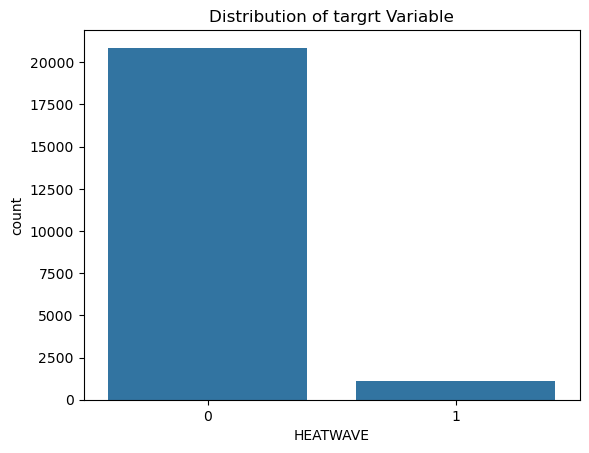

In [36]:
sns.countplot(x='HEATWAVE',data=df)
plt.title('Distribution of targrt Variable')
plt.show()

In [37]:
df['HEATWAVE'].value_counts(normalize=True)

HEATWAVE
0    0.949995
1    0.050005
Name: proportion, dtype: float64

In [38]:
print(df.groupby('HEATWAVE')['TMAX'].describe())

            count        mean       std        min        25%         50%  \
HEATWAVE                                                                    
0         20860.0  309.630225  4.557357  289.82178  306.87048  310.773315   
1          1098.0  317.293795  0.850478  316.32788  316.64020  317.058105   

                 75%        max  
HEATWAVE                         
0         313.079658  316.32740  
1         317.725950  320.95996  


## 4. Model Pipeline & Evaluation

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
x=df.drop(columns=['HEATWAVE','DATE'])
y=df['HEATWAVE']
num_cols=x.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols=['DISTRICT']

In [41]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42,stratify= y)
preprocessor=ColumnTransformer(transformers=[(
    'num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scalar',  StandardScaler())
    ]),num_cols),
    ('cat',Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]),cat_cols)
])
model_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(class_weight='balanced',random_state=42))
])

model_pipeline.fit(x_train, y_train)
y_pred=model_pipeline.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4172
           1       1.00      1.00      1.00       220

    accuracy                           1.00      4392
   macro avg       1.00      1.00      1.00      4392
weighted avg       1.00      1.00      1.00      4392

[[4172    0]
 [   0  220]]


In [42]:
importances = model_pipeline.named_steps['model'].feature_importances_
feature_names = (num_cols + 
    list(model_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(cat_cols)))

import pandas as pd
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

TMAX             0.259937
TMIN             0.235279
TEMP2M           0.195842
TMAX_rolling3    0.114460
TMAX_lag1        0.049300
SOILT1           0.046050
BLH              0.030940
MSLP             0.028850
EVAP             0.011351
MONTH            0.006182
dtype: float64
